In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import seaborn as sns

In [2]:
df=pd.read_csv("housing.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
def find_anamolies(df):
    anamolies=[]

    data_std=statistics.stdev(df)
    data_mean=statistics.mean(df)

    anamoly_cuttoff=data_std*3

    lower_limit=data_mean-anamoly_cuttoff
    upper_limit=data_mean+anamoly_cuttoff


    for outliers in df:
        if outliers>upper_limit or outliers<lower_limit:
            anamolies.append(outliers)
    return anamolies

In [11]:
df.population

0         322.0
1        2401.0
2         496.0
3         558.0
4         565.0
          ...  
20635     845.0
20636     356.0
20637    1007.0
20638     741.0
20639    1387.0
Name: population, Length: 20640, dtype: float64

In [12]:
l1=find_anamolies(df['population'])
len(l1)

342

In [ ]:
len(df) #total no of ouliers in the population column is in percentage is 0.5% .If we need the data in normal distribution percentage of outliers should be less than 0.3% .

20640

In [ ]:
df.population.skew() #positive skewness is present in the population column.

np.float64(4.93585822672712)

<Axes: xlabel='population', ylabel='Density'>

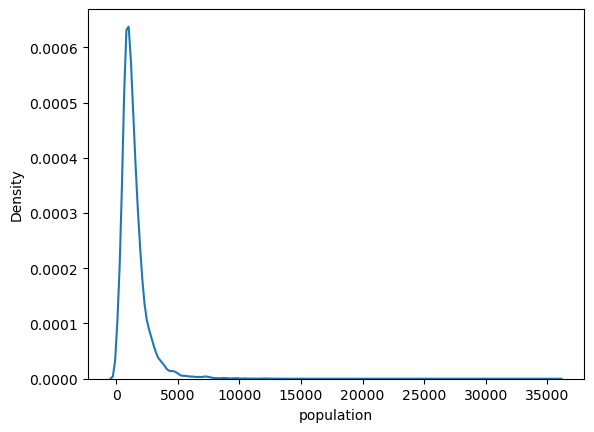

In [17]:
sns.kdeplot(df['population'])

In [25]:
df['population']=np.log(df['population'])

In [26]:
df.population.skew() #after log transformation the skewness is reduced 

np.float64(-7.487557481374824)

<Axes: xlabel='population', ylabel='Density'>

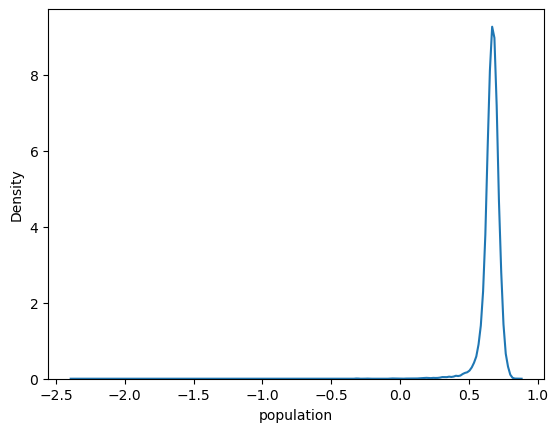

In [27]:
sns.kdeplot(df['population'])

<Axes: ylabel='population'>

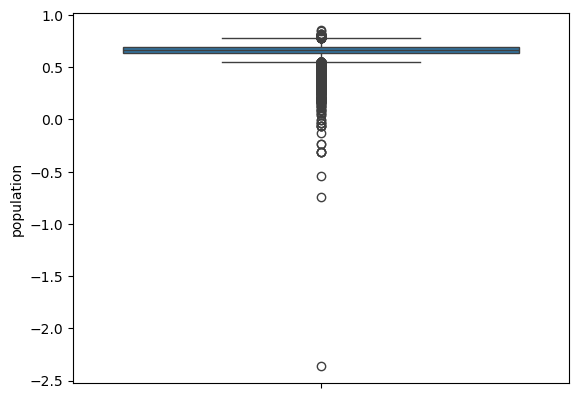

In [36]:
sns.boxplot(df['population'])

np.float64(-7.487557481374824)

In [37]:
#inter quartile range
list1=[43,47,45,46,44,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65 
    ]
len(list1)

23

In [38]:
max(list1)

65

In [39]:
min(list1)

43

In [40]:
statistics.mean(list1)

54

In [41]:
sorted_list=sorted(list1)

In [42]:
sorted_list

[43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65]

In [ ]:
#to find 90th percentile,starts multiplying the length of the list with 0.9 and then round it to the nearest integer and then find the value at that index in the sorted list.
#e.g. 90th percentile = 0.9*len(list1) = 0.9*23=20.7 ~ 21, so the value at index 21 in the sorted list is 63, which is the 90th percentile.